# 02 — Reprodução parcial e materiais visuais

Executamos os mecanismos de propagação/fusão em um grafo **proxy RGB/posição**. Não carregamos SD2 ou checkpoints Diffuse2Seg. A geometria é uma cena toy; três sementes variam somente ruído. [Protocolo e diferenças](../notes/experimental_report.md).

In [1]:
from pathlib import Path
import json
from IPython.display import display, Image
import os
root = Path(os.environ.get("SEMINAR4_ROOT", "seminar_4")).resolve()
if not root.exists():
    root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
assert (root / "articles/2609.06491v1.pdf").exists()
print("Seminário:", root)

Seminário: /home/matheus/Documentos/mestrado/repositories/matheus-983-tp558/seminar_4


## 1. Executar e verificar

A referência conhecida não entra na afinidade ou nos prompts. O caso linear é comparado à solução fechada; os controles incluem matching sem duplicação.

In [2]:
import importlib.util
spec = importlib.util.spec_from_file_location("seminar4_experiment", root / "experiments/scripts/experiment.py")
experiment = importlib.util.module_from_spec(spec)
spec.loader.exec_module(experiment)
experiment.main()

{
  "summary": [
    {
      "p": 2.0,
      "recall_mean": 0.561111111111111,
      "recall_std": 0.09622504486493764,
      "iou_mean": 0.7347944074095923
    },
    {
      "p": 1.6,
      "recall_mean": 0.24999999999999992,
      "recall_std": 3.3993498887762956e-17,
      "iou_mean": 0.3567708333333333
    },
    {
      "p": 1.2,
      "recall_mean": 0.4499999999999999,
      "recall_std": 0.0,
      "iou_mean": 0.5268656716417911
    }
  ],
  "checks": {
    "linear_closed_form_max_error": 1.9026563657931206e-09,
    "checks": "passed"
  },
  "elapsed_seconds": 4.589933063994977
}


## 2. Entradas, intermediários e saídas

As figuras mostram mapas realmente calculados pelo solver. As cores de snapshots são normalizadas por painel: não comparar amplitude entre frames.

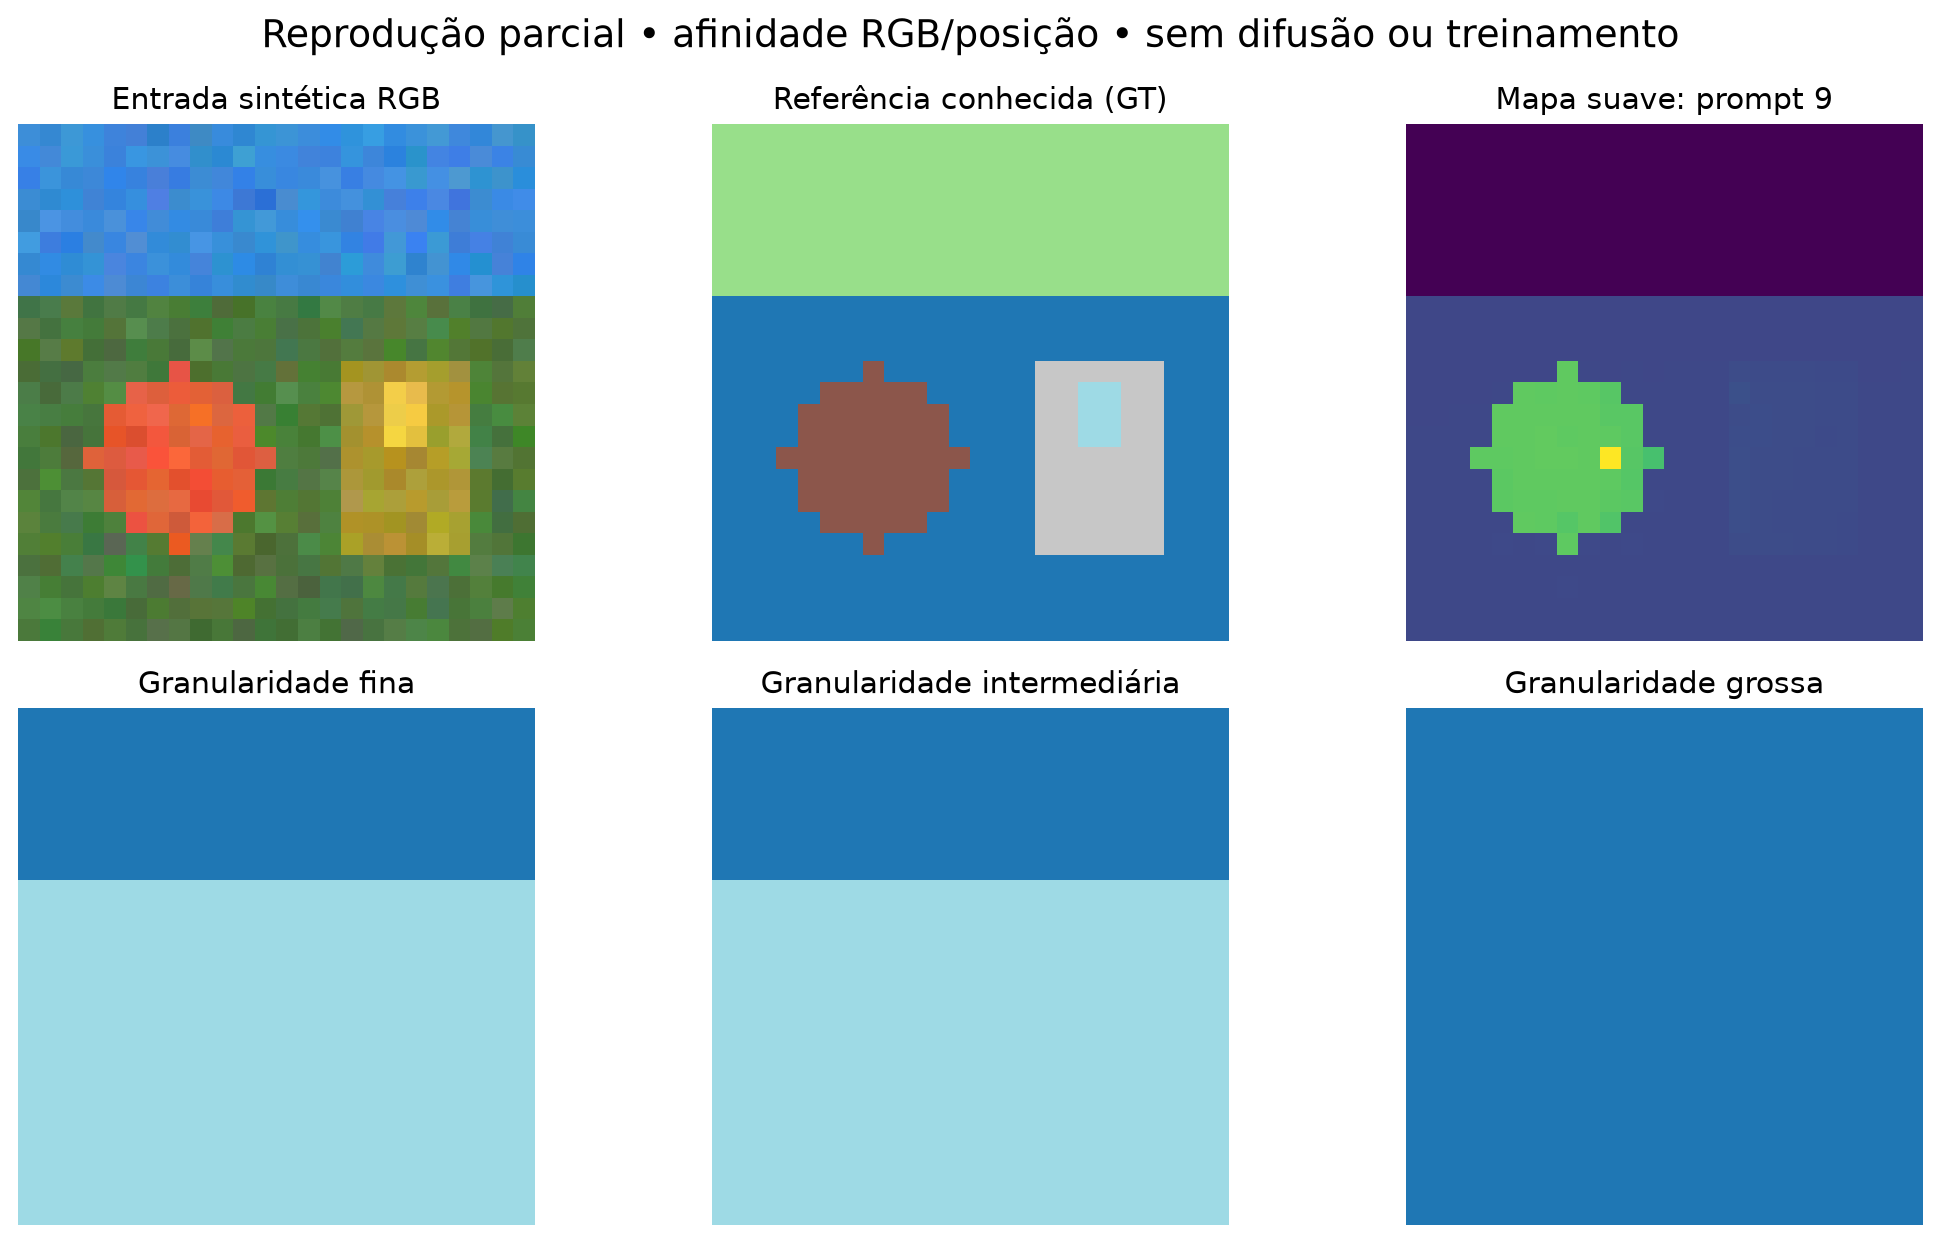

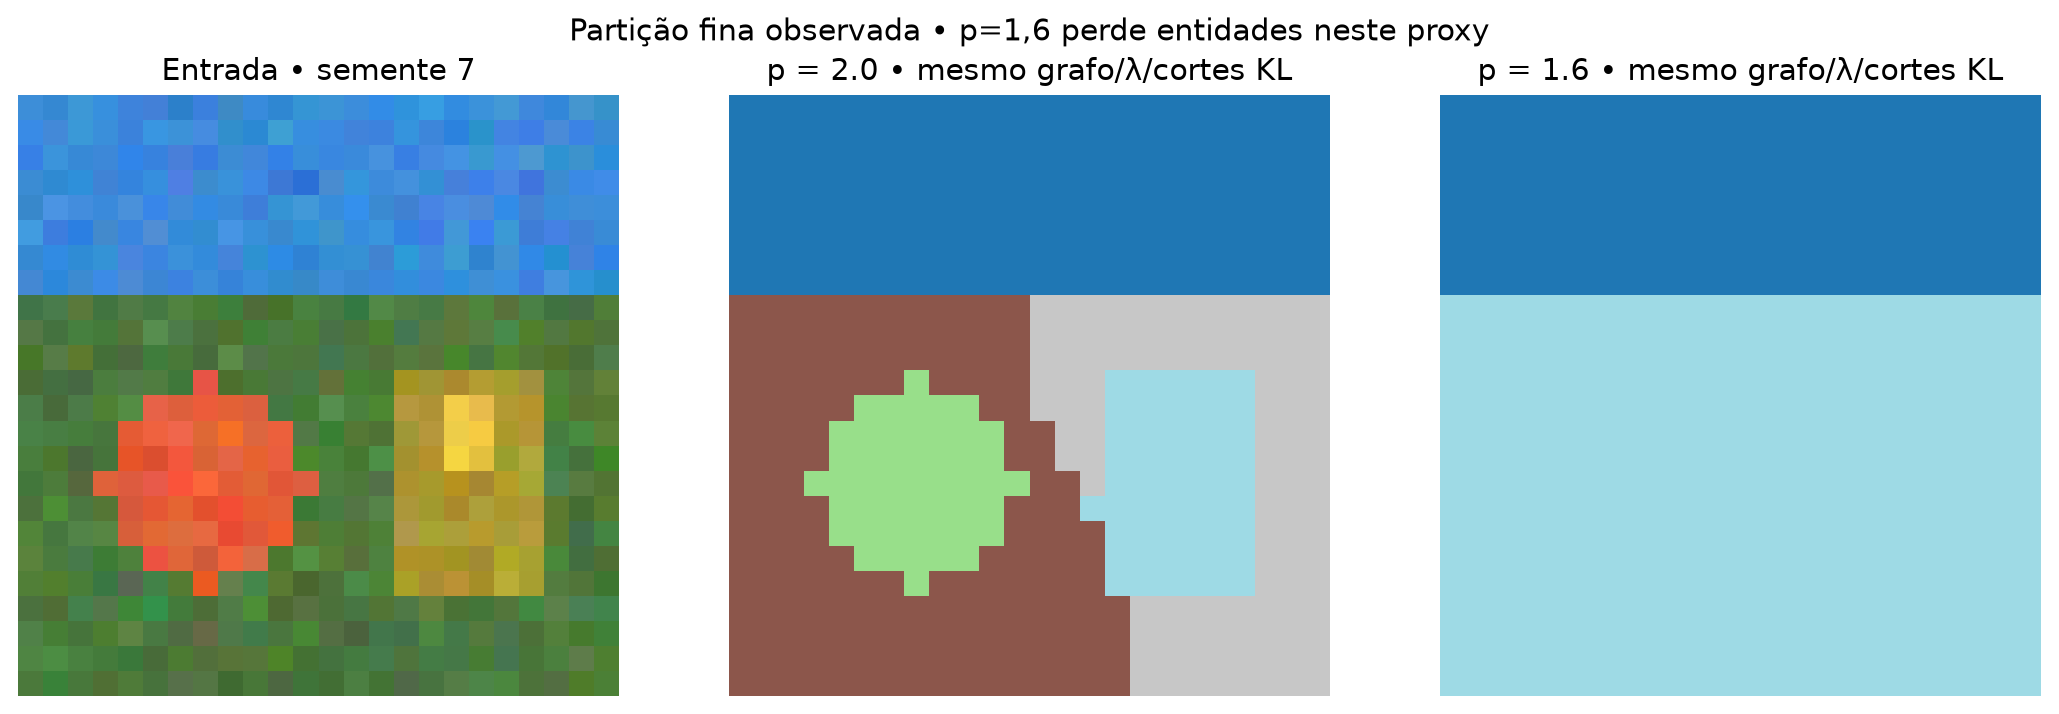

In [3]:
display(Image(filename=str(root / "data/outputs/toy_pipeline.png"), width=1100))
display(Image(filename=str(root / "data/outputs/toy_comparison.png"), width=1100))

## 3. Resultados medidos

Recall toy nos limiares IoU0,50…0,95, matching greedy 1:1 por IoU. **Não é COCO AR1000**. Reportamos mean ± std amostral, sem teste de significância.

p=2.0: 56.11% ± 9.62 p.p.
p=1.6: 25.00% ± 0.00 p.p.
p=1.2: 45.00% ± 0.00 p.p.


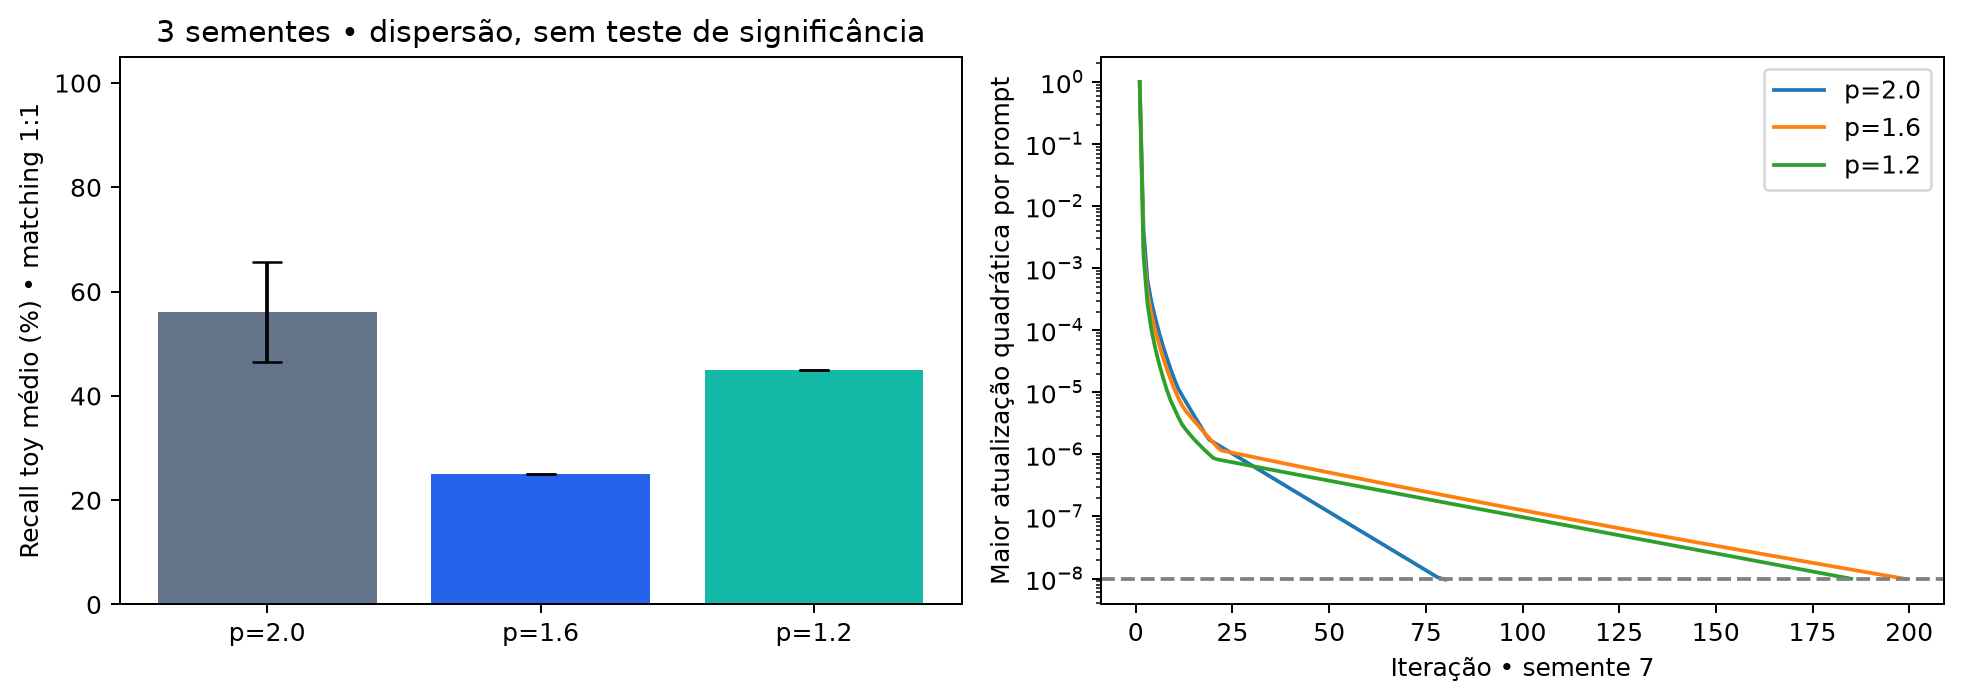

In [4]:
protocol = json.loads((root / "experiments/results/protocol.json").read_text())
for row in protocol["summary"]:
    print(f"p={row['p']}: {100*row['recall_mean']:.2f}% ± {100*row['recall_std']:.2f} p.p.")
assert protocol["checks"]["checks"] == "passed"
assert protocol["checks"]["linear_closed_form_max_error"] < 1e-7
display(Image(filename=str(root / "data/outputs/toy_results.png"), width=1100))

O ganho publicado de propagação não linear **não foi reproduzido neste proxy**. O p atua em conjunto com afinidade, λ, escala, parada e fusão KL. p=2 foi melhor aqui. Esta discrepância não valida nem refuta o benchmark SD2; mostra o limite da simplificação.

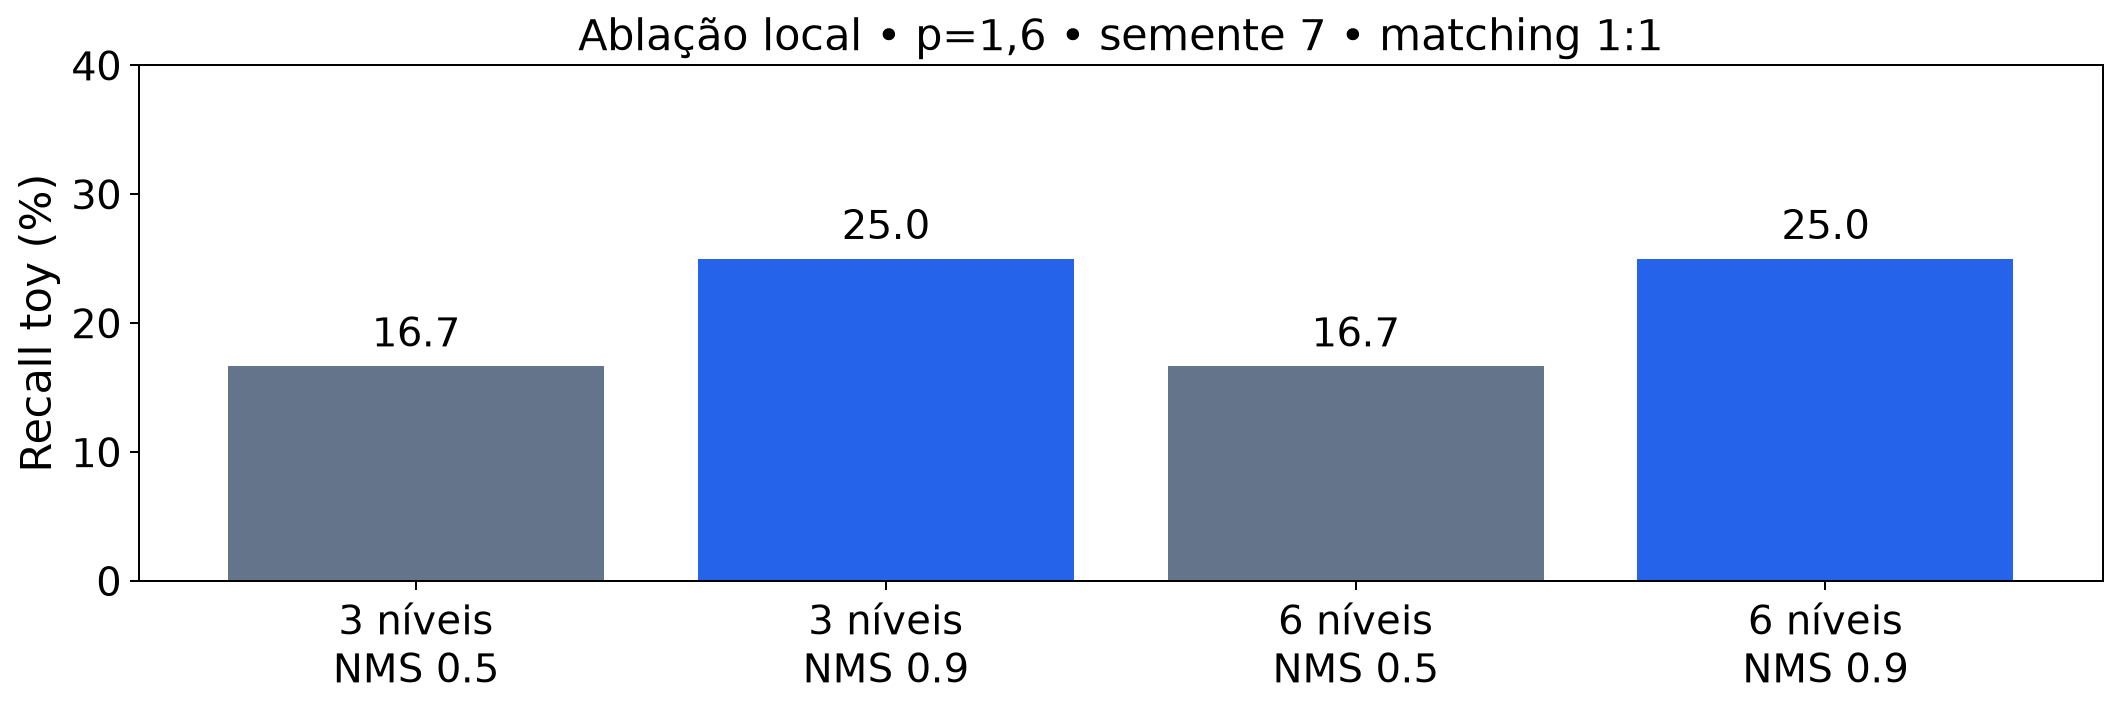

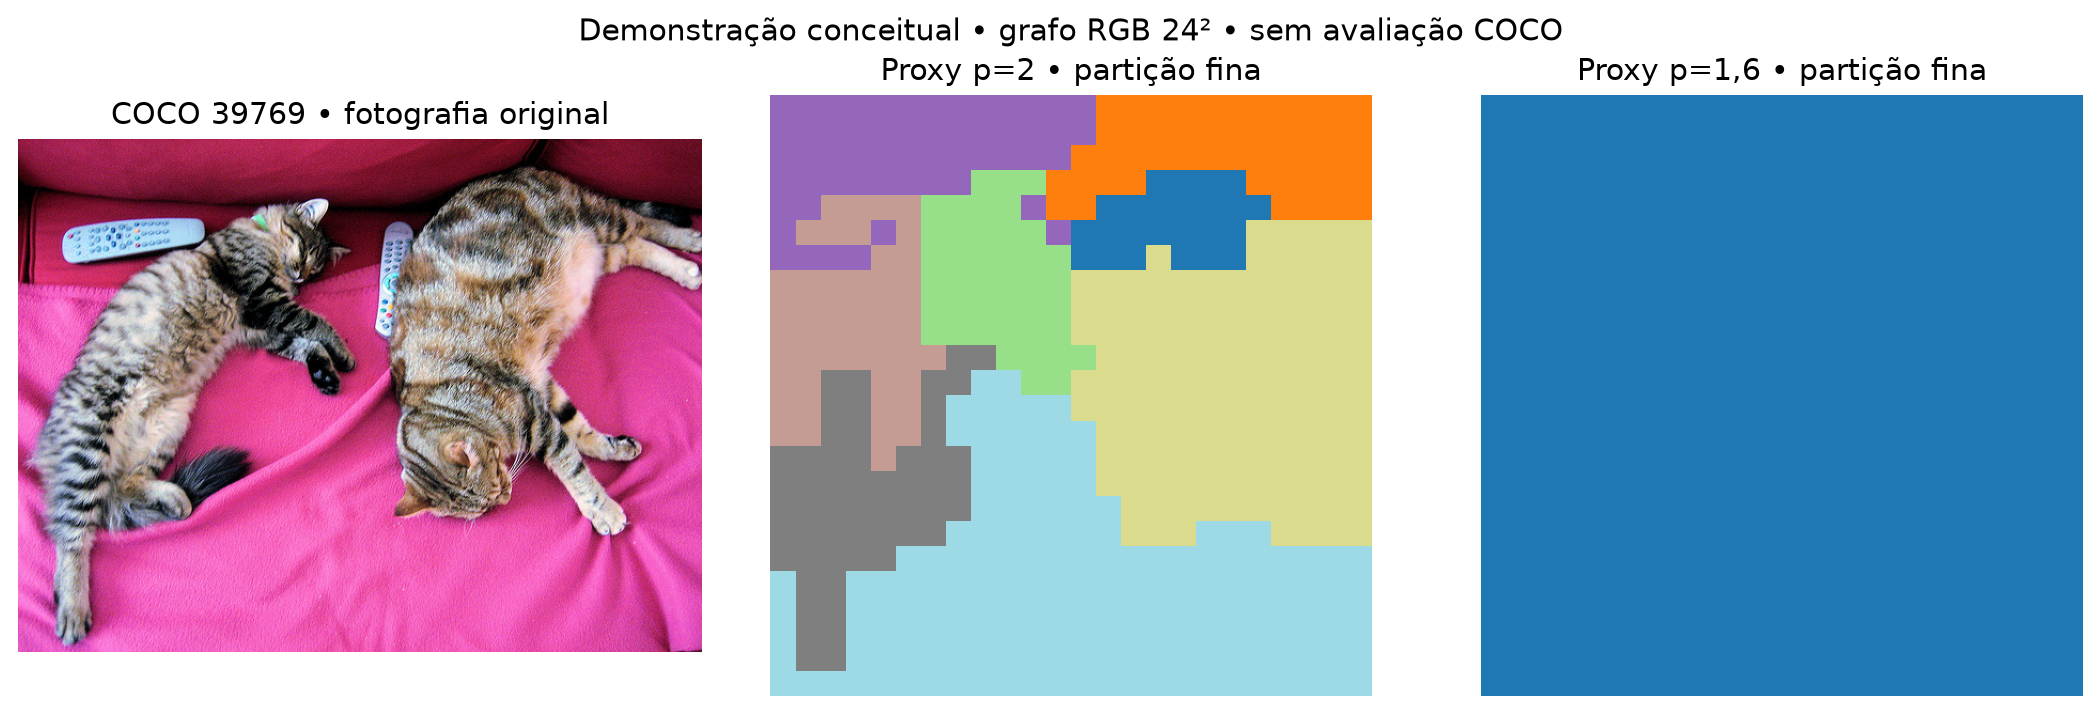

In [5]:
display(Image(filename=str(root / "assets/figures/toy_ablations.png"), width=1000))
display(Image(filename=str(root / "data/outputs/coco_concept.png"), width=1100))

## 4. Animações Manim prontas

As quatro cenas seguem o fundo escuro do ciclo3. Pipeline é um diagrama do paper; propagação/hierarquia/resultados usam dados do proxy. MP4s não ficam embutidos no PPTX; inserir manualmente nos slides indicados no roteiro. Regenerar: `python3 seminar_4/run.py animations`.

In [6]:
from IPython.display import Video
scenes = ["PipelineDiffuse2Seg", "PropagacaoPrompt", "HierarquiaNMS", "ResultadosLocais"]
for scene in scenes:
    video = root / "data/outputs/manim" / f"{scene}.mp4"
    assert video.exists(), video
    print(scene, round(video.stat().st_size/1024), "KiB")
    display(Video(filename=str(video), embed=True, width=960))

PipelineDiffuse2Seg 545 KiB


PropagacaoPrompt 540 KiB


HierarquiaNMS 439 KiB


ResultadosLocais 218 KiB


## 5. Apresentação e documentação

[PPTX](../presentation/TP558_Diffuse2Seg.pptx) • [PDF](../presentation/TP558_Diffuse2Seg.pdf) • [Roteiro de fala](../presentation/speaker_guide.md) • [README](../README.md). Slides: 32 principais + 4 de apoio; cerca de35min. As referências de resultados publicados e resultados locais estão explícitas.